In [1]:
import gzip
from pathlib import Path
import shutil
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

TRAIN = False
MODEL_PATH = Path("tinystories_transformer.pt")
TOKENIZER_PATH = Path("tinystories_tokenizer.json")

if not TRAIN:
    for path in (MODEL_PATH, TOKENIZER_PATH):
        if not path.exists():
            compressed_path = path.with_suffix(path.suffix + ".gz")
            if not compressed_path.exists():
                raise FileNotFoundError(f"Missing {path} and {compressed_path}")
            with gzip.open(compressed_path, "rb") as source, path.open("wb") as target:
                shutil.copyfileobj(source, target)
            print(f"Extracted {path}")

dataset = load_dataset("roneneldan/TinyStories")


print(dataset["train"][0]['text'])
dataset

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

In [2]:
train_dataset = dataset['train'].map(
    lambda x: {'word_count':len(x['text'].split())}
)
train_dataset

Dataset({
    features: ['text', 'word_count'],
    num_rows: 2119719
})

In [3]:
train_counts = train_dataset.with_format('numpy')['word_count'][:]
assert(len(train_counts)==len(train_dataset))
train_counts

array([134, 142, 168, ..., 128, 113,  45], shape=(2119719,))

In [4]:
val_dataset = dataset['validation'].map(
    lambda x: {'word_count':len(x['text'].split())}
)
val_dataset

Dataset({
    features: ['text', 'word_count'],
    num_rows: 21990
})

In [5]:
val_counts = val_dataset.with_format('numpy')['word_count'][:]
assert(len(val_counts)==len(val_dataset))
val_counts

array([ 64, 235, 105, ..., 147, 138, 217], shape=(21990,))

Total Samples: 2,119,719
Shortest: 0
Median:   153
Mean:     175
90%:      273
95%:      349
99%:      493
Longest:  963


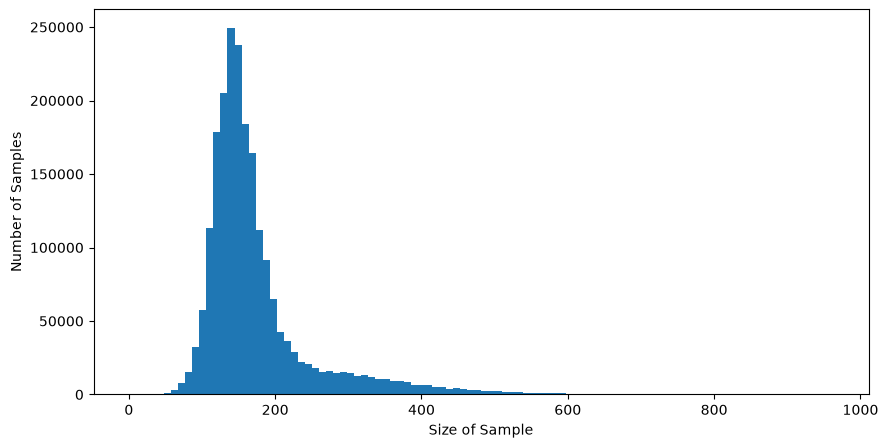

In [6]:
def show_dataset_statistics(counts):
    print(f"Total Samples: {len(counts):,}")
    print(f"Shortest: {counts.min():,}")
    print(f"Median:   {np.median(counts):,.0f}")
    print(f"Mean:     {counts.mean():,.0f}")
    print(f"90%:      {np.percentile(counts, 90):,.0f}")
    print(f"95%:      {np.percentile(counts, 95):,.0f}")
    print(f"99%:      {np.percentile(counts, 99):,.0f}")
    print(f"Longest:  {counts.max():,}")
    
    plt.figure(figsize=(10, 5))
    
    plt.hist(
        counts,
        bins=100,
    )
    
    plt.xlabel("Size of Sample")
    plt.ylabel("Number of Samples")    
    plt.show()


show_dataset_statistics(train_counts)

Total Samples: 2
Shortest: 902
Median:   932
Mean:     932
90%:      957
95%:      960
99%:      962
Longest:  963


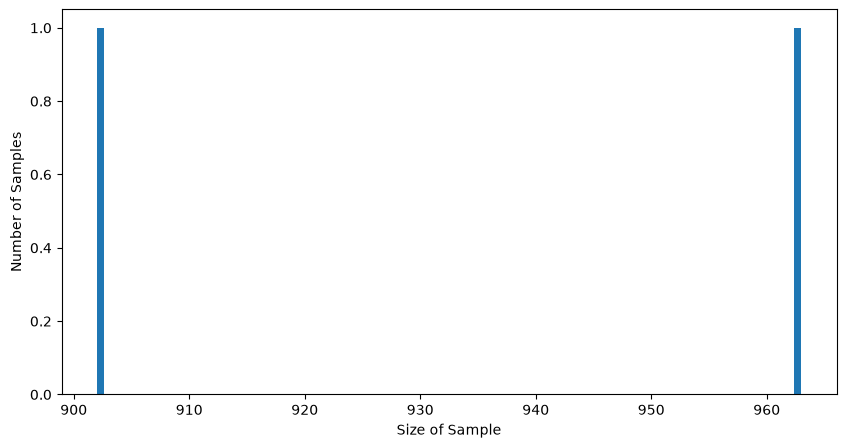

In [7]:
show_dataset_statistics(train_counts[train_counts>900])

Total Samples: 2,113,075
Shortest: 0
Median:   153
Mean:     174
90%:      269
95%:      343
99%:      470
Longest:  600


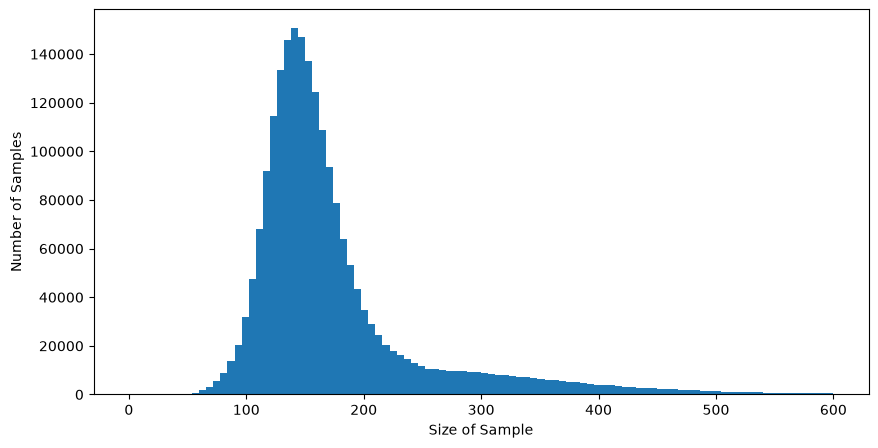

In [8]:
MAX_LEN = 600
show_dataset_statistics(train_counts[train_counts<=MAX_LEN])

Total Samples: 4,795
Shortest: 550
Median:   572
Mean:     573
90%:      594
95%:      597
99%:      600
Longest:  600


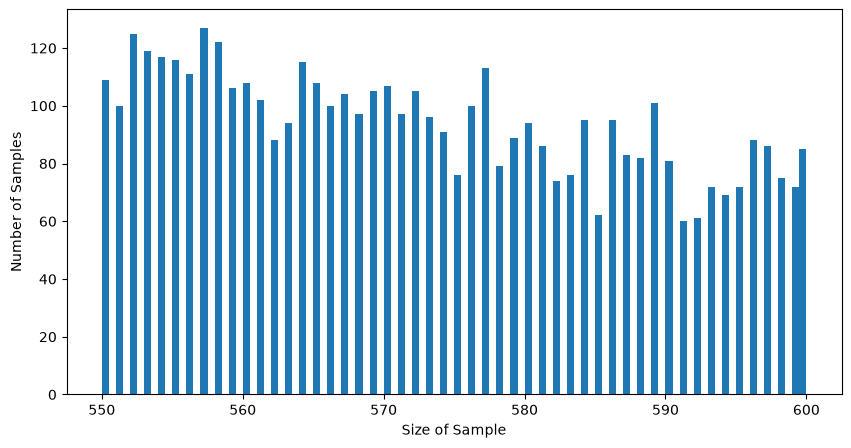

In [9]:
MAYBE_TOO_BIG=550
show_dataset_statistics(train_counts[
    (train_counts<=MAX_LEN)
    & (train_counts>=MAYBE_TOO_BIG)
    ])

Total Samples: 21,990
Shortest: 13
Median:   151
Mean:     171
90%:      252
95%:      332
99%:      476
Longest:  841


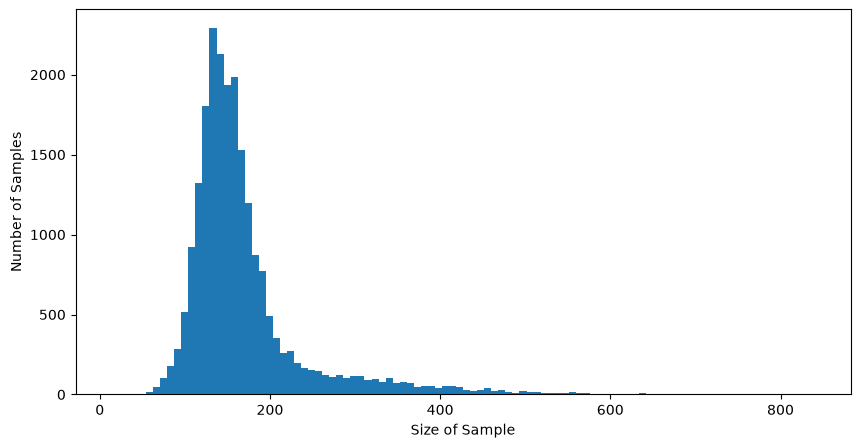

In [10]:
show_dataset_statistics(val_counts)

Total Samples: 45
Shortest: 550
Median:   565
Mean:     568
90%:      589
95%:      594
99%:      599
Longest:  600


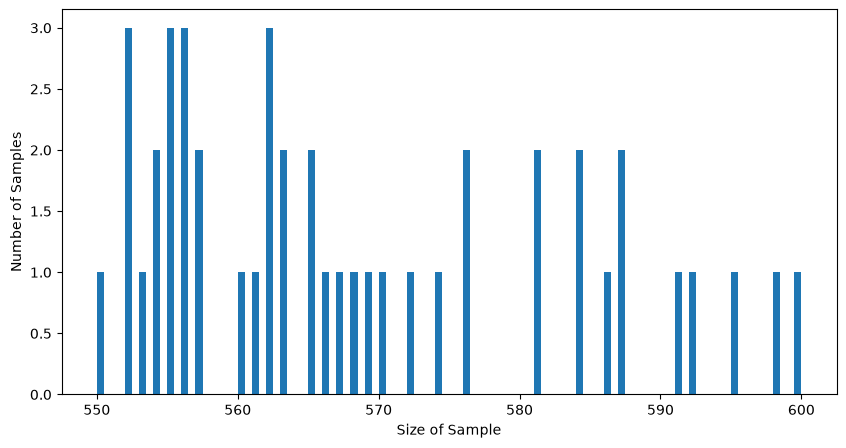

In [11]:
show_dataset_statistics(val_counts[(val_counts<=MAX_LEN)&(val_counts>=MAYBE_TOO_BIG)])

Total Samples: 2
Shortest: 840
Median:   840
Mean:     840
90%:      841
95%:      841
99%:      841
Longest:  841


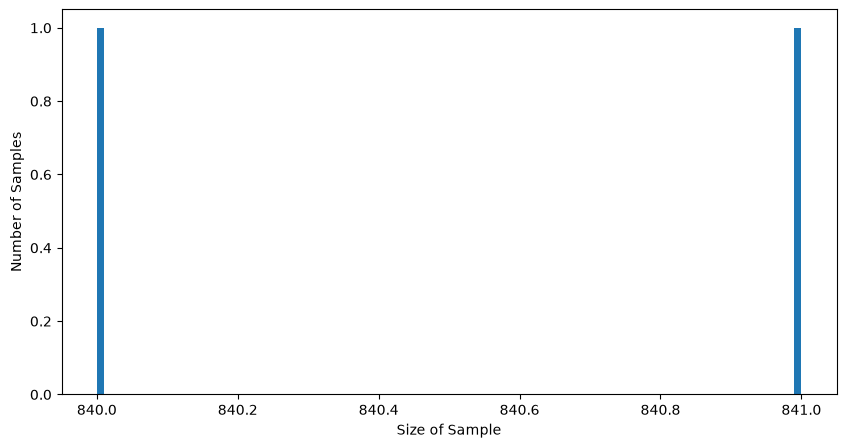

In [12]:
show_dataset_statistics(val_counts[val_counts>=800])

Total Samples: 481
Shortest: 800
Median:   815
Mean:     820
90%:      843
95%:      855
99%:      887
Longest:  963


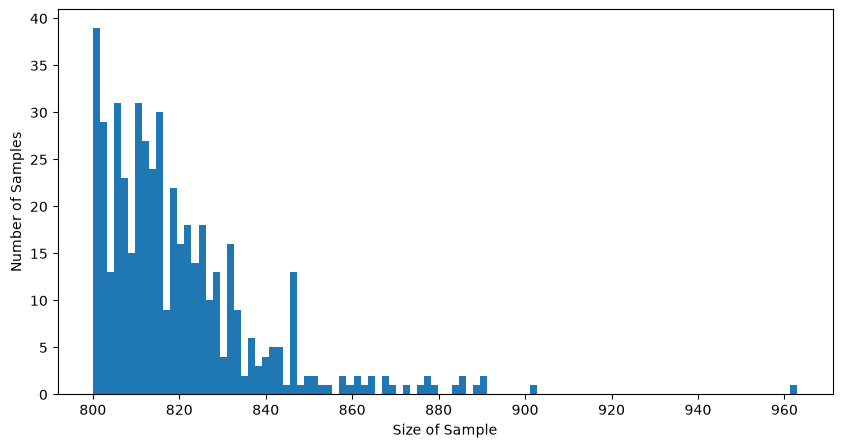

In [13]:
show_dataset_statistics(train_counts[train_counts>=800])

# Implementing a Transformer

transformers were first invented in [this revolutionary paper](https://arxiv.org/abs/1706.03762) they are a meaningfull fundemental improvment over anything we had before that point. The core idea is that rather than doing O(N) compute on a sequnce we do O(N^2) and allow every possible comperison to any previous token.

But first we do need to find a way to make text into continious numbers. The typical way to do this is to combine letters/bytes into tokens. The naive way would be to just use words. But we can be a bit more clever and use BPE, which basically finds common combinations of letters in the data. This is nicer because it means there are no "holes" in our tokenizer, it can tokenize any text.



In [14]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing


# How many normal text tokens the tokenizer should learn.
TEXT_VOCAB_SIZE = 2048


tokenizer = Tokenizer(BPE()) if TRAIN else Tokenizer.from_file(str(TOKENIZER_PATH))


# Split text into word/punctuation-sized chunks before BPE.
#
# For example:
#
#     "SCP-173 is dangerous."
#
# becomes roughly:
#
#     ["SCP", "-", "173", "is", "dangerous", "."]
#
# BPE can then learn useful pieces inside those chunks.
if TRAIN:
    tokenizer.pre_tokenizer = Whitespace()


# The trainer decides how the BPE vocabulary is learned.
trainer = BpeTrainer(
    vocab_size=TEXT_VOCAB_SIZE,

    # A pair must appear at least twice before BPE considers
    # creating a token for it.
    min_frequency=2,
)


# Train directly from the text column of our SCP dataset.
#
# train_from_iterator() lets us give the tokenizer strings one
# at a time instead of combining the whole dataset into one giant
# Python string.
def batch_iterator(dataset, batch_size=1000):
    dataset = dataset.select_columns("text")

    for batch in dataset.iter(batch_size=batch_size):
        yield batch["text"]


trainer = BpeTrainer(
    vocab_size=TEXT_VOCAB_SIZE,
    min_frequency=2,
    show_progress=True,
)

if TRAIN:
    tokenizer.train_from_iterator(
        batch_iterator(train_dataset),
        trainer=trainer,
    )
# ------------------------------------------------------------
# Model-only tokens
# ------------------------------------------------------------
#
# We need some special tokens for our training
# These are not text and so we dont put them in the tokenizer
#
# If we did the tokenizer can actually find and encode them (thanks hugginface)

TEXT_VOCAB_SIZE = tokenizer.get_vocab_size()

BOT_ID = TEXT_VOCAB_SIZE
EOT_ID = TEXT_VOCAB_SIZE + 1
PAD_ID = TEXT_VOCAB_SIZE + 2

#add our special EOT BOT tokens

tokenizer.post_processor = TemplateProcessing(
    single="<BOT> $A <EOT>",
    special_tokens=[
        ("<BOT>", BOT_ID),
        ("<EOT>", EOT_ID),
    ],
)

if TRAIN:
    tokenizer.save(str(TOKENIZER_PATH))

# The neural network needs outputs for both:
#
#   - normal text tokens
#   - our three model-only tokens
#
MODEL_VOCAB_SIZE = TEXT_VOCAB_SIZE + 3


print(f"Text vocabulary size:  {TEXT_VOCAB_SIZE}")
print(f"BOT ID:                {BOT_ID}")
print(f"EOT ID:                {EOT_ID}")
print(f"PAD ID:                {PAD_ID}")
print(f"Model vocabulary size: {MODEL_VOCAB_SIZE}")

Text vocabulary size:  2048
BOT ID:                2048
EOT ID:                2049
PAD ID:                2050
Model vocabulary size: 2051


In [15]:
np.array(tokenizer.encode(train_dataset['text'][0]).ids)

array([2048,  302,  239,   11,   63,  281,  320,  374,  233,  446,   63,
        634,  194,  176,  201,  533,   13,  203,  543,  180,  183,  841,
         68,  366,  301,   82,  175,  254,  230,  180,  633,  180,  183,
       1831,   13,  233,  317,  175,  768,  172,  634,  194,  230,  201,
        257,   11,  237,  224,  332,  212,   85,   63, 1566,  186,  201,
        286, 1866,   13,  233,  343,  175,  201,  257,  174,  219,   11,
          1,  380,   11,   40,  446,  591,  634,  194,   13,  702,  235,
        768,  180,  230,  333,  174,  212,   85,  244,  286, 1866,  349,
        550,  257,  373,  174,  219,   11,    1,  673,   11,  233,   11,
        241,  341,  768,  172,  634,  194,  174, 1084,  477,  286, 1866,
        296, 1947,   11,  255, 1408,  172,  634,  194,  174,  212,   85,
        173,  172, 1566,  186,  233,    6,   81,  286, 1866,   13,  272,
        183,  275,  841,   68,  366,  301,   82,  256,  323,  633,  255,
        310,  485,  875,  174, 1488,  600,  401,   

In [16]:
text = "hello <BOT> world <EOT>"

encoding = tokenizer.encode(text)

print("Tokens:", encoding.tokens)
print("IDs:   ", encoding.ids)

# The post-processor should add BOT/EOT only at the boundaries.
assert encoding.ids[0] == BOT_ID
assert encoding.ids[-1] == EOT_ID

# The literal text "<BOT>" and "<EOT>" inside the input must NOT
# turn into the model-only IDs.
assert BOT_ID not in encoding.ids[1:-1]
assert EOT_ID not in encoding.ids[1:-1]

print("Passed: literal <BOT>/<EOT> text cannot produce model-only IDs.")

Tokens: ['<BOT>', 'hello', '<', 'B', 'O', 'T', '>', 'world', '<', 'E', 'O', 'T', '>', '<EOT>']
IDs:    [2048, 1697, 27, 33, 46, 51, 29, 1060, 27, 36, 46, 51, 29, 2049]
Passed: literal <BOT>/<EOT> text cannot produce model-only IDs.


In [17]:
def tokenize_batch(batch):
    encodings = tokenizer.encode_batch(batch["text"])
    tokens = [np.array(encoding.ids) for encoding in encodings]

    return {
        "tokens": tokens,
        "token_count": [len(ids) for ids in tokens],
    }


train_dataset = train_dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=128,
)
train_dataset

Dataset({
    features: ['text', 'word_count', 'tokens', 'token_count'],
    num_rows: 2119719
})

In [18]:
val_dataset = val_dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=128,
)
val_dataset

Dataset({
    features: ['text', 'word_count', 'tokens', 'token_count'],
    num_rows: 21990
})

In [19]:
train_counts = train_dataset.with_format('numpy')['token_count'][:]
assert(len(train_counts)==len(train_dataset))
train_counts

array([185, 189, 226, ..., 168, 141,  59], shape=(2119719,))

In [20]:
val_counts = val_dataset.with_format('numpy')['token_count'][:]
assert(len(val_counts)==len(val_dataset))
val_counts

array([ 91, 325, 129, ..., 212, 205, 264], shape=(21990,))

Total Samples: 2,119,719
Shortest: 2
Median:   205
Mean:     236
90%:      370
95%:      475
99%:      674
Longest:  1,974


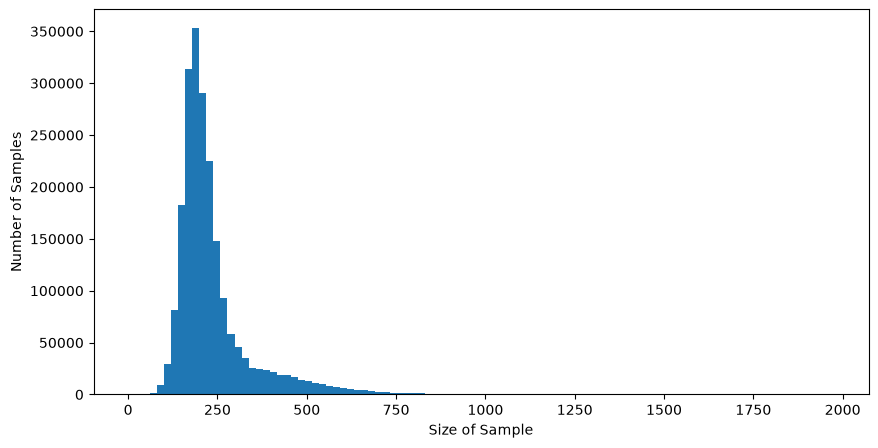

In [21]:
show_dataset_statistics(train_counts)

Total Samples: 21,990
Shortest: 17
Median:   202
Mean:     230
90%:      341
95%:      449
99%:      651
Longest:  1,176


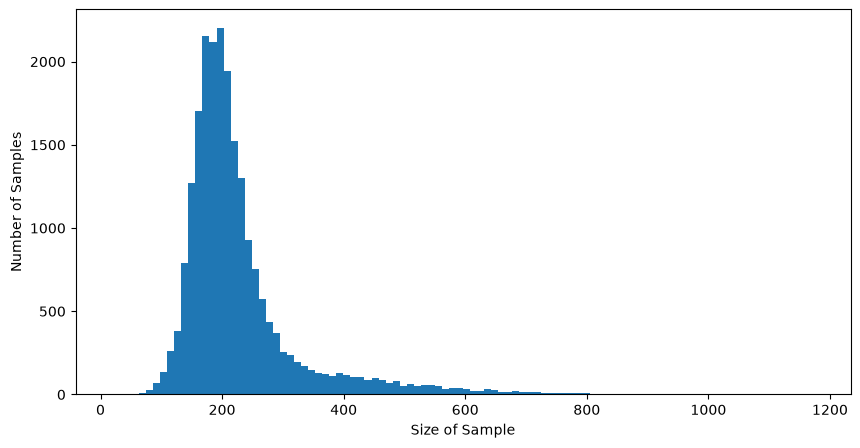

In [22]:
show_dataset_statistics(val_counts)

Total Samples: 2,102,554
Shortest: 2
Median:   204
Mean:     232
90%:      358
95%:      455
99%:      603
Longest:  700


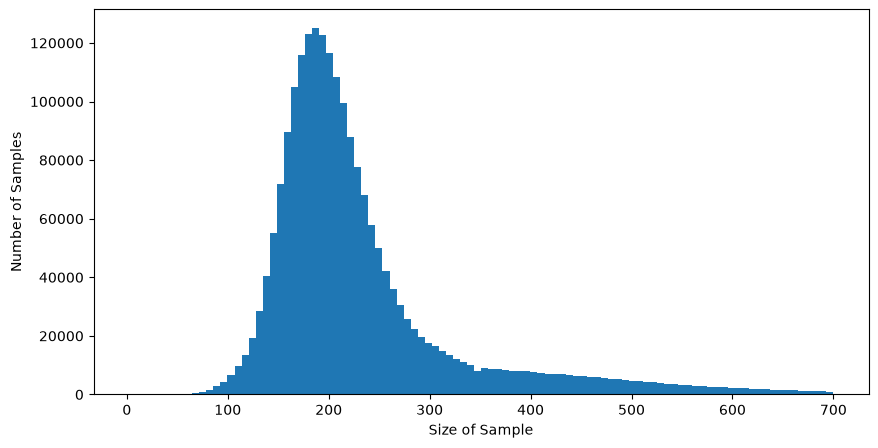

In [23]:
MAX_LEN = 700
show_dataset_statistics(train_counts[train_counts<=MAX_LEN])

Total Samples: 22,085
Shortest: 600
Median:   640
Mean:     643
90%:      686
95%:      693
99%:      699
Longest:  700


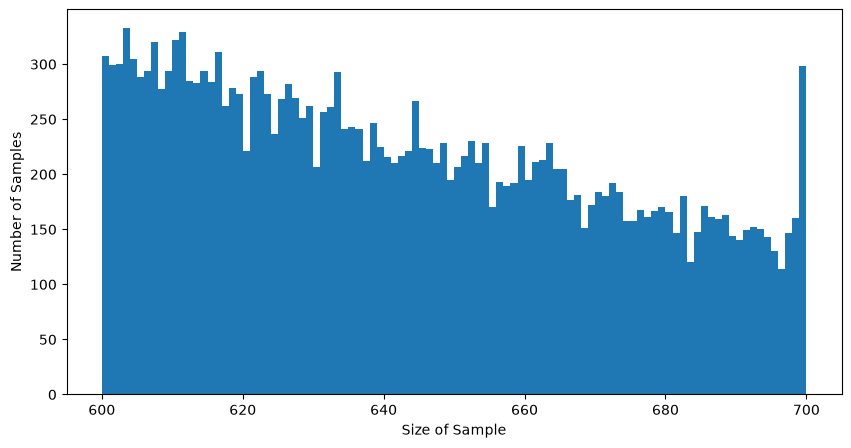

In [24]:
MAYBE_TOO_BIG = 600
show_dataset_statistics(train_counts[(train_counts<=MAX_LEN) & (train_counts>=MAYBE_TOO_BIG)])

Total Samples: 193
Shortest: 600
Median:   640
Mean:     645
90%:      684
95%:      693
99%:      699
Longest:  700


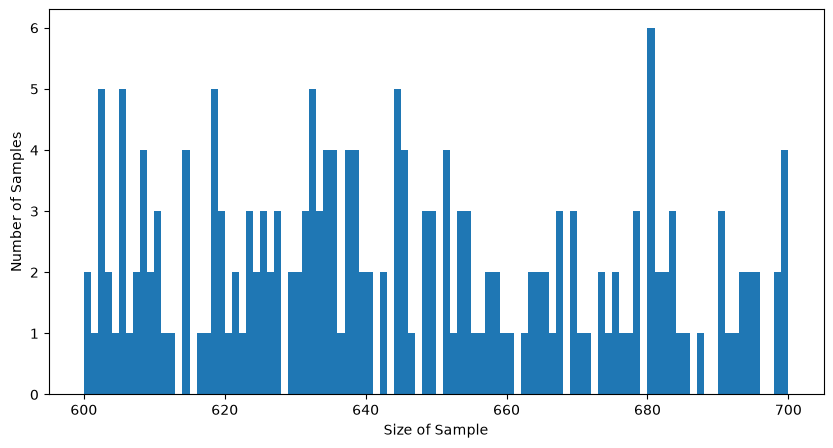

In [25]:
show_dataset_statistics(val_counts[(val_counts<=MAX_LEN) & (val_counts>=MAYBE_TOO_BIG)])

Total Samples: 144
Shortest: 701
Median:   787
Mean:     829
90%:      1,014
95%:      1,061
99%:      1,097
Longest:  1,176


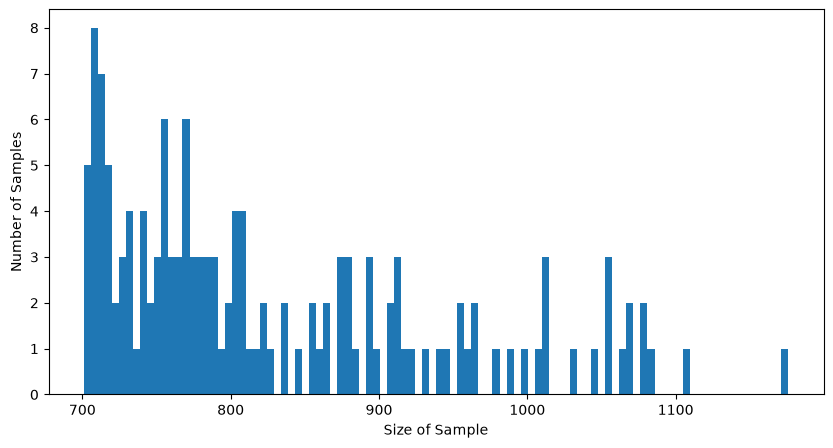

In [26]:
show_dataset_statistics(val_counts[val_counts>MAX_LEN])

In [27]:
print(f"Validation samples over max length: {100 * (val_counts > MAX_LEN).mean():.2f}%")

Validation samples over max length: 0.65%


In [28]:
# train_dataset.with_format('numpy')['tokens'][:]

In [29]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    max_len = min(
        max(len(x) for x in batch),
        MAX_LEN,
    )

    tokens = np.stack([
        np.pad(
            x[:max_len],
            (0, max_len - min(len(x), max_len)),
            constant_values=PAD_ID,
        )
        for x in batch
    ])

    return torch.from_numpy(tokens)


train_loader = DataLoader(
    train_dataset.with_format('numpy')['tokens'][:],
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,#let pytorch go brr
)

train_loader

In [30]:
val_loader = DataLoader(
    val_dataset.with_format('numpy')['tokens'][:],
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,#let pytorch go brr
)
val_loader

In [44]:
import torch

device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

print(device)

cuda


In [32]:
batch = next(iter(train_loader))

print(batch.shape)
print(batch)

#this goes brr
_ = batch.to(device, non_blocking=True)

torch.Size([64, 671])
tensor([[2048,  311,  321,  ..., 2050, 2050, 2050],
        [2048,  311,  321,  ..., 2050, 2050, 2050],
        [2048,  311,  321,  ..., 2050, 2050, 2050],
        ...,
        [2048,  311,  321,  ..., 2050, 2050, 2050],
        [2048,  311,  321,  ..., 2050, 2050, 2050],
        [2048,  311,  321,  ..., 2050, 2050, 2050]])


# Implementing a Transformer

transformers were first invented in [this revolutionary paper](https://arxiv.org/abs/1706.03762) they are a meaningfull fundemental improvment over anything we had before that point. The core idea is that rather than doing O(N) compute on a sequnce we do O(N^2) and allow every possible comperison to any previous token.

But first we do need to find a way to make text into continious numbers. The typical way to do this is to combine letters/bytes into tokens. The naive way would be to just use words. But we can be a bit more clever and use BPE, which basically finds common combinations of letters in the data. This is nicer because it means there are no "holes" in our tokenizer, it can tokenize any text.



In [33]:
import torch
from torch import nn
import math

In [34]:
#Students would need to implement this
#We probably want to make a test somewhere that checks this for them
#I can make a module
def attention_math(q, k, v, mask, scale):
    scores = q @ k.transpose(-2, -1)
    scores = scores * scale
    T = q.shape[1]
    mask = mask[:T, :T]
    scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ v

In [35]:
class Attention(nn.Module):
    def __init__(self,d):
        super().__init__()

        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(MAX_LEN, MAX_LEN, dtype=torch.bool))
        )

        self.register_buffer(
            "scale",
            torch.tensor(d ** -0.5)
        )

    def forward(self, x):
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        return attention_math(q,k,v,self.mask,self.scale)

Attention(100)

Attention(
  (q): Linear(in_features=100, out_features=100, bias=False)
  (k): Linear(in_features=100, out_features=100, bias=False)
  (v): Linear(in_features=100, out_features=100, bias=False)
)

In [36]:
class Embed(nn.Module):
    def __init__(self, d):
        super().__init__()

        self.pos = nn.Embedding(MAX_LEN, d)
        self.tok = nn.Embedding(MODEL_VOCAB_SIZE, d)
        self.dropout = nn.Dropout(0.1)

    def forward(self, ids):
        positions = torch.arange(ids.shape[1], device=ids.device)

        return self.dropout(self.tok(ids) + self.pos(positions))

Embed(30)

Embed(
  (pos): Embedding(700, 30)
  (tok): Embedding(2051, 30)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [37]:
class Block(nn.Module):
    def __init__(self, d):
        super().__init__()

        self.norm1 = nn.LayerNorm(d)
        self.attention = Attention(d)

        self.norm2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(
            nn.Linear(d, 4 * d),
            nn.GELU(),
            nn.Linear(4 * d, d),
        )

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

Block(7)

Block(
  (norm1): LayerNorm((7,), eps=1e-05, elementwise_affine=True, bias=True)
  (attention): Attention(
    (q): Linear(in_features=7, out_features=7, bias=False)
    (k): Linear(in_features=7, out_features=7, bias=False)
    (v): Linear(in_features=7, out_features=7, bias=False)
  )
  (norm2): LayerNorm((7,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=7, out_features=28, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=28, out_features=7, bias=True)
  )
)

In [38]:
class Transformer(nn.Module):
    def __init__(self, d, layers):
        super().__init__()

        self.embed = Embed(d)

        self.blocks = nn.Sequential(*[
            Block(d)
            for _ in range(layers)
        ])

        self.norm = nn.LayerNorm(d)

        self.head = nn.Linear(
            d,
            MODEL_VOCAB_SIZE,
            bias=False,
        )

    def forward(self, ids):
        x = self.embed(ids)
        x = self.blocks(x)
        x = self.norm(x)

        return self.head(x)

Transformer(23,2)

Transformer(
  (embed): Embed(
    (pos): Embedding(700, 23)
    (tok): Embedding(2051, 23)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((23,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): Attention(
        (q): Linear(in_features=23, out_features=23, bias=False)
        (k): Linear(in_features=23, out_features=23, bias=False)
        (v): Linear(in_features=23, out_features=23, bias=False)
      )
      (norm2): LayerNorm((23,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=23, out_features=92, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=92, out_features=23, bias=True)
      )
    )
    (1): Block(
      (norm1): LayerNorm((23,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): Attention(
        (q): Linear(in_features=23, out_features=23, bias=False)
        (k): Linear(in_features=2

# actual train runs

In [39]:
import torch
import torch.nn.functional as F
from tqdm import tqdm


def batch_metrics(pred, actual):
    loss = F.cross_entropy(
        pred.transpose(1, 2),
        actual,
        ignore_index=PAD_ID,
    )

    predicted = pred.argmax(dim=-1)
    mask = actual != PAD_ID

    correct = ((predicted == actual) & mask).sum().item()
    tokens = mask.sum().item()

    return loss, correct, tokens


def train_epoch(model, opt, dataset):
    model.train()
    model.to(device)

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    progress = tqdm(dataset)

    for batch in progress:
        opt.zero_grad()

        batch = batch.to(device, non_blocking=True)

        pred = model(batch[:, :-1])
        actual = batch[:, 1:]

        loss, correct, tokens = batch_metrics(pred, actual)

        loss.backward()
        opt.step()

        total_loss += loss.item() * tokens
        total_correct += correct
        total_tokens += tokens

        progress.set_postfix(
            loss=f"{total_loss / total_tokens:.4f}",
            acc=f"{total_correct / total_tokens:.2%}",
        )

    return {
        "loss": total_loss / total_tokens,
        "accuracy": total_correct / total_tokens,
    }


@torch.inference_mode()
def val_epoch(model, dataset):
    model.eval()
    model.to(device)

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    progress = tqdm(dataset)

    for batch in progress:
        batch = batch.to(device, non_blocking=True)

        pred = model(batch[:, :-1])
        actual = batch[:, 1:]

        loss, correct, tokens = batch_metrics(pred, actual)

        total_loss += loss.item() * tokens
        total_correct += correct
        total_tokens += tokens

        progress.set_postfix(
            loss=f"{total_loss / total_tokens:.4f}",
            acc=f"{total_correct / total_tokens:.2%}",
        )

    return {
        "loss": total_loss / total_tokens,
        "accuracy": total_correct / total_tokens,
    }

In [40]:
model = Transformer(512, 8).to(device)

if TRAIN:
    opt = torch.optim.Adam(model.parameters())

    for epoch in range(3):
        print(f"Epoch {epoch + 1}/3")
        print("train:", train_epoch(model, opt, train_loader))
        print("validation:", val_epoch(model, val_loader))
        torch.save(model.state_dict(), MODEL_PATH)
else:
    model.load_state_dict(
        torch.load(MODEL_PATH, map_location=device, weights_only=True)
    )
    model.eval()
    print(f"Loaded {MODEL_PATH}")

Loaded tinystories_transformer.pt


In [41]:
val_epoch(model,val_loader)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 344/344 [00:28<00:00, 12.05it/s, acc=66.21%, loss=1.2461]


{'loss': 1.2460768672594251, 'accuracy': 0.6620763312791578}

# Generate

In [42]:
@torch.inference_mode()
def generate(
    model,
    ids,
    max_new_tokens,
    beam_size=4,
    candidates_per_beam=4,
    temperature=0.8,
    top_k=40,
    eos_id=None,
    dropout=False,
):
    if dropout:
        model.train()
    else:
        model.eval()

    if ids.ndim == 1:
        ids = ids.unsqueeze(0)

    ids = ids.to(next(model.parameters()).device)

    beams = [(ids, 0.0)]

    for _ in range(max_new_tokens):
        candidates = []

        for seq, score in beams:
            if eos_id is not None and seq[0, -1].item() == eos_id:
                candidates.append((seq, score))
                continue

            logits = model(seq)[:, -1]
            logits = logits / temperature

            if top_k is not None:
                k = min(top_k, logits.shape[-1])
                values, _ = torch.topk(logits, k)
                cutoff = values[:, -1, None]
                logits = logits.masked_fill(
                    logits < cutoff,
                    float("-inf"),
                )

            log_probs = torch.log_softmax(logits, dim=-1)
            probs = log_probs.exp()

            sampled = torch.multinomial(
                probs,
                num_samples=candidates_per_beam,
                replacement=False,
            )

            for token in sampled[0]:
                token = token.view(1, 1)

                new_seq = torch.cat((seq, token), dim=1)

                new_score = (
                    score
                    + log_probs[0, token.item()].item()
                )

                candidates.append((new_seq, new_score))

        candidates.sort(
            key=lambda x: x[1],
            reverse=True,
        )

        beams = candidates[:beam_size]

        if eos_id is not None and all(
            seq[0, -1].item() == eos_id
            for seq, _ in beams
        ):
            break

    # Return normal CPU token lists.
    return [
        seq[0].cpu().tolist()
        for seq, _ in beams
    ]

In [43]:
prompt = "Once upon a time"
ids = torch.tensor(
    tokenizer.encode(prompt).ids,
    dtype=torch.long,
)

generated = generate(
    model,
    ids,
    max_new_tokens=200,
)

text = tokenizer.decode(generated[0])
print(text)

Once upon a time , there was a little girl named Lily . She loved to play with her toys and run around outside . One day , she found a shiny rock on the ground . She picked it up and showed it to her mom . " Look , Mommy ! I found a pretty rock !" Lily said . Her mom smiled and said , " That ' s a nice rock , Lily . Let ' s put it in your pocket so we don ' t lo se it ." Lily nodded and put the rock in her pocket . Later that day , Lily and her mom went to the park . They played on the swings and the slide . Lily was having so much fun that she forgot about the rock in her pocket . When it was time to go home , she remembered the shiny rock in her pocket . " Mommy , can we go back to the park tomorrow ?" she asked . Her mom smiled and said , " Of course , Lily . Let ' s go back to the park tomorrow ." And so , Lily went to bed
